# N-Body Simulations

## Initial conditions for both systems 

In the simulation code the gravitational constant G is set as $1$ to make the calculations easier. So we set the length unit as $R=1$ AU and the mass unit as $M=1 M_{\odot}$.

and so we evaluate the conversion time unit using the relation:
$$
t = \sqrt{\frac{R^3}{G M}} \approx 5 \times 10^6 \ \text{s} \approx 0.16 \ \text{yr}
$$

Orbits are planar due to conservation of angular momentum. Gravity is a central force and so it does not change the angular momentum of the system. 
$$
\tau = \vec{r} \times \vec{F} = \frac{dL}{dt} = 0
$$
and so we can choose our coordinate system such that the angular momentum vector aligns with the z-axis. This implies the objects move entirely in the $x$-$y$ plane, so we set $z = 0$ and $v_z = 0$.

If we start the motion of the objects on the perihelion or the aphelion then the radial velocity is $0$ and the tangential velocity is all we need.

## Part 1: Sun-Earth System
The mass of the Sun is set at $1 M_{\odot}$ and according to that the mass of the Earth is $3 \times 10^{-6} M_{\odot}$

Let's make some approximations to demonstrate that the Earth is orbiting the Sun in a circular orbit.

In the inertial reference frame the distance of the Sun from the center of mass is 
$$
r_{sun} = a\frac{M_{Earth}}{M_{Sun} + M_{Earth}} \approx 450 \text{ km}
$$

Considering that the radius of the Sun is $7 \times 10^5$ km we can say that the center of mass is roughly at the Sun's position. The same logic can be applied to the Sun's velocity: 
$$
v_{sun} = \frac{M_{Earth}}{M_{Sun} + M_{Earth}} v 
$$
where $v$ is the velocity of the Earth relative to the Sun. Since $M_{Sun} \gg M_{Earth}$ we can approximate $v_{sun} \approx 0$ m/s.

The velocity of the Earth relative to the Sun is given by the relation 
$$
v_{earth} = \sqrt{\frac{G M_{Sun}}{r(M_{Sun} + M_{Earth})}} \approx 1 \ \text{au / internal time unit}
$$ 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical Constants & Internal Units ---
astronomical_unit = 1.496e13 # cm
mass_of_sun = 1.989e33 # g
mass_of_earth = 5.972e27 # g
G = 6.674e-8 # cm^3 g^-1 s^-2

internal_time = np.sqrt(astronomical_unit**3 / (G * mass_of_sun))
seconds_in_year = 365.25 * 24 * 60 * 60  # using exactly 365.25
internal_time_years = internal_time / seconds_in_year

print(f"Internal time unit: {internal_time:.2e} s ({internal_time_years:.4f} years)")

Internal time unit: 5.02e+06 s (0.1591 years)


In [2]:
# --- Setup Initial Conditions for Sun-Earth ---
r = 1 # AU
m_sun = 1 # Solar masses
m_earth = 3e-6 # Solar masses
m_total = m_sun + m_earth

year_in_internal_units = seconds_in_year / internal_time
a = (m_total * (year_in_internal_units / (2*np.pi))**2)**(1/3)
v_rel = np.sqrt(m_total * (2/r - 1/a))

x_sun = -m_earth / m_total * r
x_earth = m_sun / m_total * r
v_y_sun = -(m_earth / m_total) * v_rel
v_y_earth = (m_sun / m_total) * v_rel

print("Initial Conditions (x, v_y):")
print(f"Sun:   x = {x_sun:10.2e}, v_y = {v_y_sun:10.2e}")
print(f"Earth: x = {x_earth:10.2e}, v_y = {v_y_earth:10.2e}")

Initial Conditions (x, v_y):
Sun:   x =  -3.00e-06, v_y =  -3.00e-06
Earth: x =   1.00e+00, v_y =   1.00e+00


**Running the integration:**

we would like to plot $\sim 100$ points for a single orbit and see what happen so we chose the output interval as $\sim 0.06$ and for the total integration time we choose $\sim 2\pi$

```bash
.\nbody_sh1.exe -d 0.03 -o 0.0628 -t 6.28 < SolarSystem.in > SolarSystem.out
```

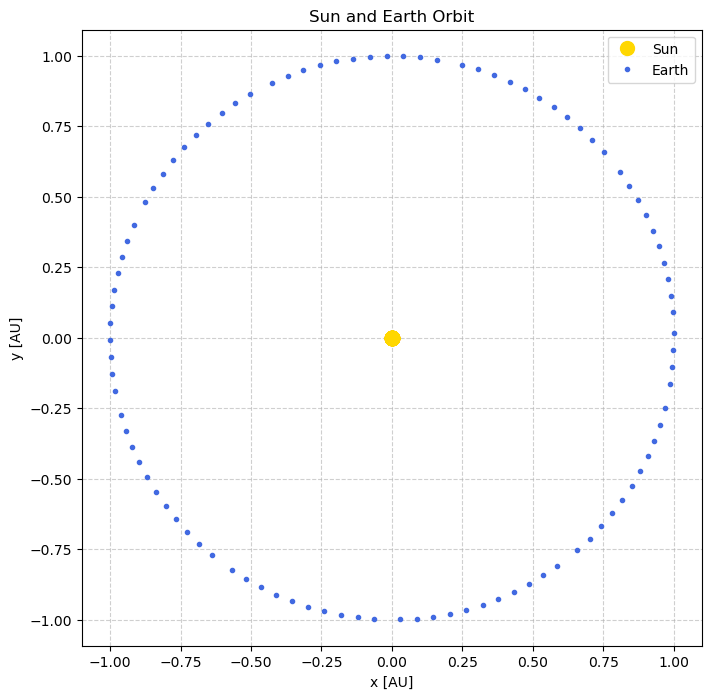

In [3]:
# --- Plotting Sun-Earth Orbit ---
sun_x, sun_y = [], []
earth_x, earth_y = [], []

with open('C:/Users/user/Downloads/nbody_sh1/SolarSystem.out', 'r') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 4):
        try:
            s = lines[i+2].split()
            e = lines[i+3].split()
            sun_x.append(float(s[1]))
            sun_y.append(float(s[2]))
            earth_x.append(float(e[1]))
            earth_y.append(float(e[2]))
        except IndexError:
            break

plt.figure(figsize=(8, 8))
plt.plot(sun_x, sun_y, 'o', color='gold', markersize=10, label='Sun')
plt.plot(earth_x, earth_y, 'o', color='royalblue', markersize=3, label='Earth')
plt.axis('equal')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Sun and Earth Orbit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Part 2: Binary Neutron Star System
In the second part, it was simulated a binary system with two $1.4 M_\odot$ neutron stars, similar the known system of PSR J0737-3039 A/B. The system has an orbital period of $2.45$ hours and an eccentricity of $e = 0.088$.

In [4]:
# --- Setup Initial Conditions for Binary Pulsar ---
m_ns1 = 1.4 # solar masses  
m_ns2 = 1.4  
m_tot = m_ns1 + m_ns2
period_hours = 2.45 
e = 0.088

# Convert period: hours -> years
period_in_years = period_hours / (365.25 * 24)

# Time unit in years (from Part 1)
time_unit_years = internal_time_years
period_internal = period_in_years / time_unit_years

# Kepler's third law: a^3 = G*M_tot * (P/(2π))^2, with G=1
a = (m_tot * (period_internal / (2 * np.pi))**2)**(1/3)
r_rel = a * (1 - e) # Relative distance at periastron
v_rel = np.sqrt(m_tot * (2/r_rel - 1/a))

x_ns1 = -m_ns2 / m_tot * r_rel
x_ns2 =  m_ns1 / m_tot * r_rel
v_ns1 = -(m_ns2 / m_tot) * v_rel
v_ns2 =  (m_ns1 / m_tot) * v_rel

print("Initial Conditions (x, v_y):")
print(f"NS1: x = {x_ns1:10.4e}, v_y = {v_ns1:10.4e}")
print(f"NS2: x = {x_ns2:10.4e}, v_y = {v_ns2:10.4e}")

Initial Conditions (x, v_y):
NS1: x = -2.7476e-03, v_y = -1.1773e+01
NS2: x = 2.7476e-03, v_y = 1.1773e+01


**Running the integration:**
```bash
.\nbody_sh1.exe -d 0.03 -o 0.0000175 -t 17.56 < BinarySystem.in > BinarySystem.out
```

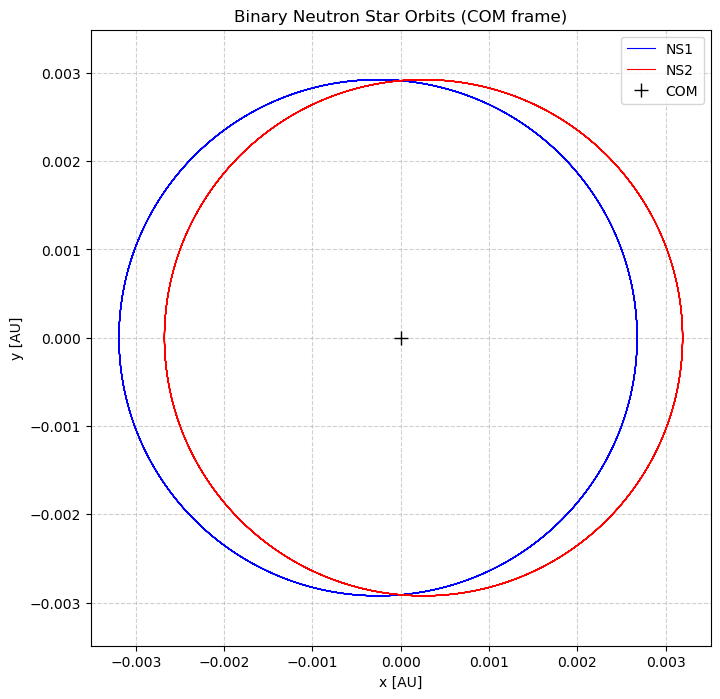

In [5]:
# --- Plotting Binary System in Center of Mass Frame ---
x1, y1 = [], []
x2, y2 = [], []

with open(r"C:\Users\user\Downloads\nbody_sh1\BinarySystem.out") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    if lines[i].strip() == '2':
        i += 2  # skip particle count + time
        v1 = lines[i].split()
        x1.append(float(v1[1])); y1.append(float(v1[2]))
        i += 1
        v2 = lines[i].split()
        x2.append(float(v2[1])); y2.append(float(v2[2]))
        i += 1
    else:
        i += 1

# Subtract center of mass to plot the actual relative orbit
xc = [(m_ns1*a + m_ns2*b)/m_tot for a, b in zip(x1, x2)]
yc = [(m_ns1*a + m_ns2*b)/m_tot for a, b in zip(y1, y2)]

x1r = [a - c for a, c in zip(x1, xc)]
y1r = [a - c for a, c in zip(y1, yc)]
x2r = [a - c for a, c in zip(x2, xc)]
y2r = [a - c for a, c in zip(y2, yc)]

plt.figure(figsize=(8, 8))
plt.plot(x1r, y1r, 'b-', lw=0.8, label='NS1')
plt.plot(x2r, y2r, 'r-', lw=0.8, label='NS2')
plt.plot(0, 0, 'k+', ms=10, label='COM')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.axis('equal')
plt.legend()
plt.title('Binary Neutron Star Orbits (COM frame)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**TO NOTE**: the system is known to have a precession of 16 degrees per year. The gravity in the simulation is Newtonian, while GR is needed to explain the precession.

# Part 3
To further investigate the binary system, we analyzed the numerical errors produced by the Hermite Scheme. The only free parameter controlling the accuracy of this scheme is $d$. We first studied the relative energy error as a function of time for different values of $d$, and found that it tends to grow slowly over time, but for $d=1$, and that it decreases strongly with $d$, until a minimum around $d\sim0.001$, after which it raises again.

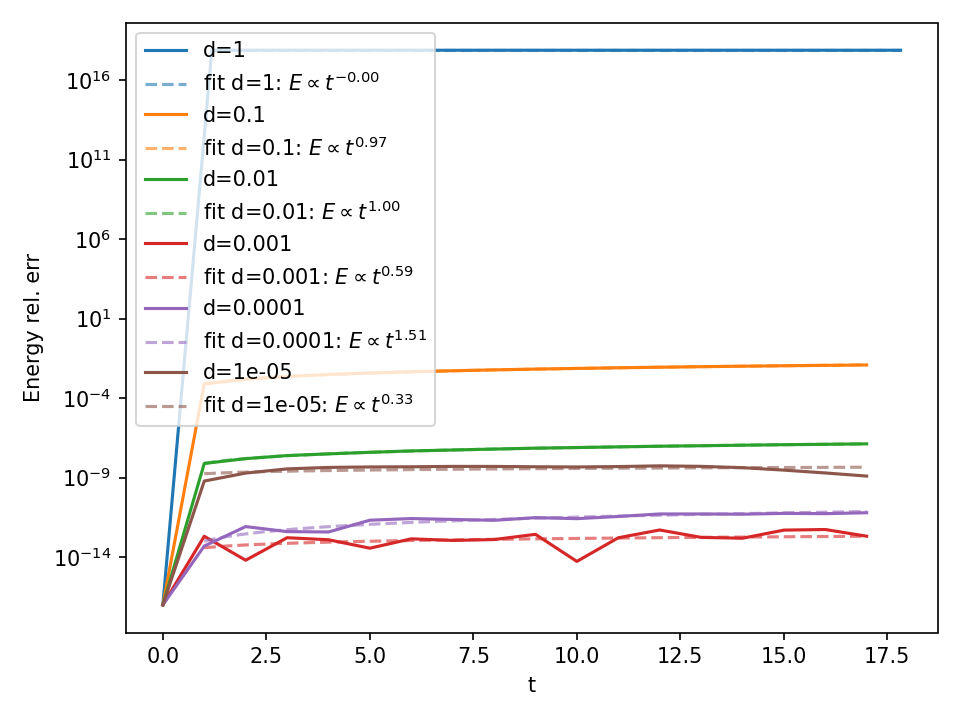

In [3]:
from IPython.display import Image
Image(r"C:\Users\andre\Downloads\energy_errors.png", width=700, height=500)

By plotting 100 consecutive orbits of the binary ($d=0.01$), we noticed that they did not perfectly overlap. As we are working in Newtonian gravity, orbital precession is not possible as potential scaling with the inverse of the radius produces closed ellipses. The simulated drift must therefore be assoociated to numerical causes. To confirm this, we measured the eccentricity from the simulation output using $e = (R_{apo} - R_{peri})/(R_{apo} + R_{peri})$ and found that its deviation from the input value of $e=0.088$ is of the order of $10^{-7}$, comparable to the energy error produced by the Hermite scheme.
In particular, we noticed how the errors for $d=1$ and $d=0.1$ produced very high errors, so high the eccentricity was far from the observed one of $0.088$.

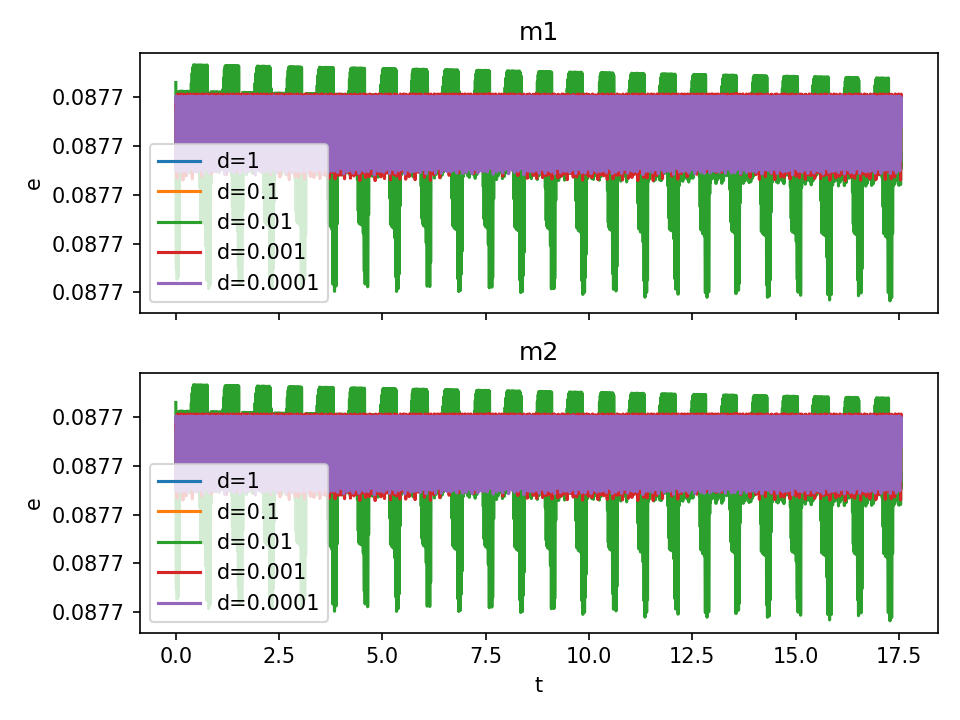

In [6]:
Image(r"C:\Users\andre\Downloads\eccentricity.png", width=700, height=500)

To investigate that, we plotted the trajectories for these two cases and we noticed that there was indeed an issue.
For $d=1$ the energy errors and therefore the errors on eccentricity were so high that the eccentricity became immediatly $e>>1$, the system became unbound and the two stars ejected far away from eachothers. 

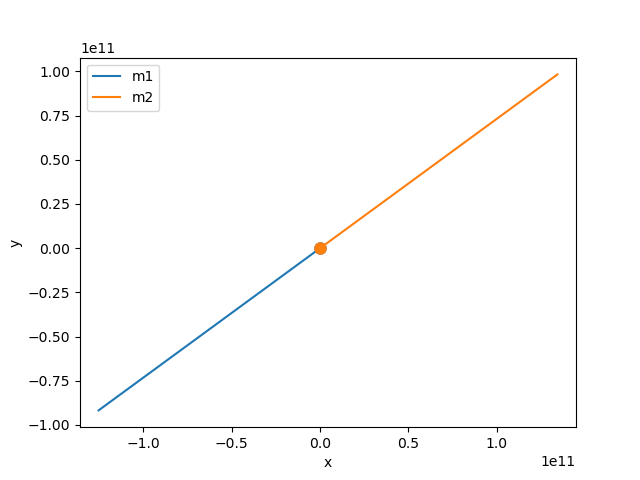

In [48]:
Image(r"C:\Users\andre\Downloads\Binaryd1_3d.png", width=700, height=500)

For $d=0.1$ and for $d=1.0\times10^{-5}$, we recover that the orbit is not immediately destroyed but the accumulated error per step is large enough that the pulsars gradually spiral inward instead of following a closed ellipse, producing a bound orbit inconsistent with Newtonian gravity. For $d=0.1$ this effect is linked to a too large time-step integration. While for $d=1.0\times10^{-5}$, the integrating time-step is so low that the step-count is high enough to produce an energy error, and thus an eccentricity error, which is bigger than the ones associated to $d=0.01$ and $d=0.001$, revealing an intrinsic computational limit.

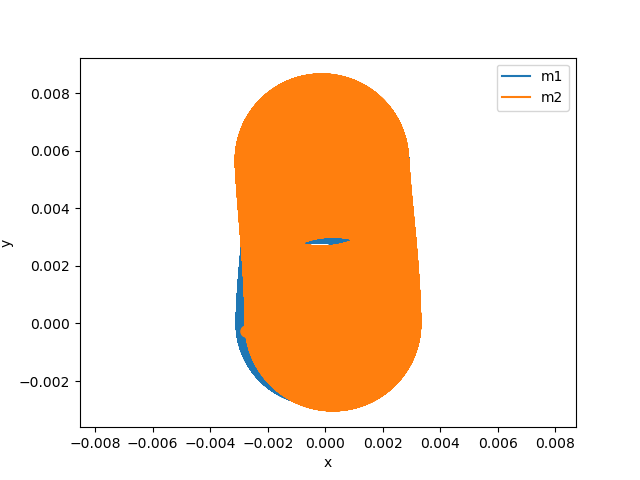

In [45]:
Image(r"C:\Users\andre\Downloads\Binaryd01_3d.png", width=700, height=500)

It must also be noticed that $d$ being too high is related to specific problem. Given a longer period, the divergence limit from the newtonian solution is higher. In fact, for $d=1$, the system Sun-Earth remains bound as the period is still sufficiently large to allow larger integration times. In addiction, the fact that for small $d$ such as $10^{-5}$--$10^{-6}$ we recover a newtonian bound orbid for the Sun-Earth system, suggests that also for low $d$ the accuracy of system with low $e$ is better. The best $d$ for the Sun-Earth system is recovered to be $d=0.0001$.